TELECOM CUSTOMER CHURN by Gothavari. V & Diwakar

IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

  

LOAD DATA

In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\91994\Downloads\OneDrive\Documents\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (7043, 21)

Columns:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


DATA PREPROCESSING

In [9]:
# Convert 'TotalCharges' to numeric and handle missing values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


# Drop customerID (irrelevant for prediction)
# Safely drop 'customerID' if it exists
if "customerID" in df.columns:
   df.drop("customerID", axis=1, inplace=True)

# Encode categorical variables

le = LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])

print("\nData Preprocessing Complete!")
print(df.info())


Data Preprocessing Complete!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMetho

EDA

In [10]:
print("\nChurn Distribution:")
print(df["Churn"].value_counts())


Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


C:\Users\91994\AppData\Local\Temp\ipykernel_10900\31801813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="coolwarm")


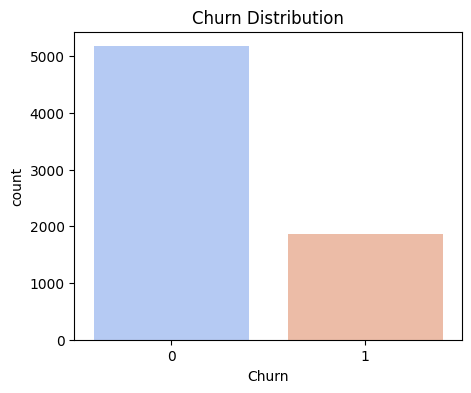

In [14]:
# Plot Churn Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, palette="coolwarm")
plt.title("Churn Distribution")
plt.show()

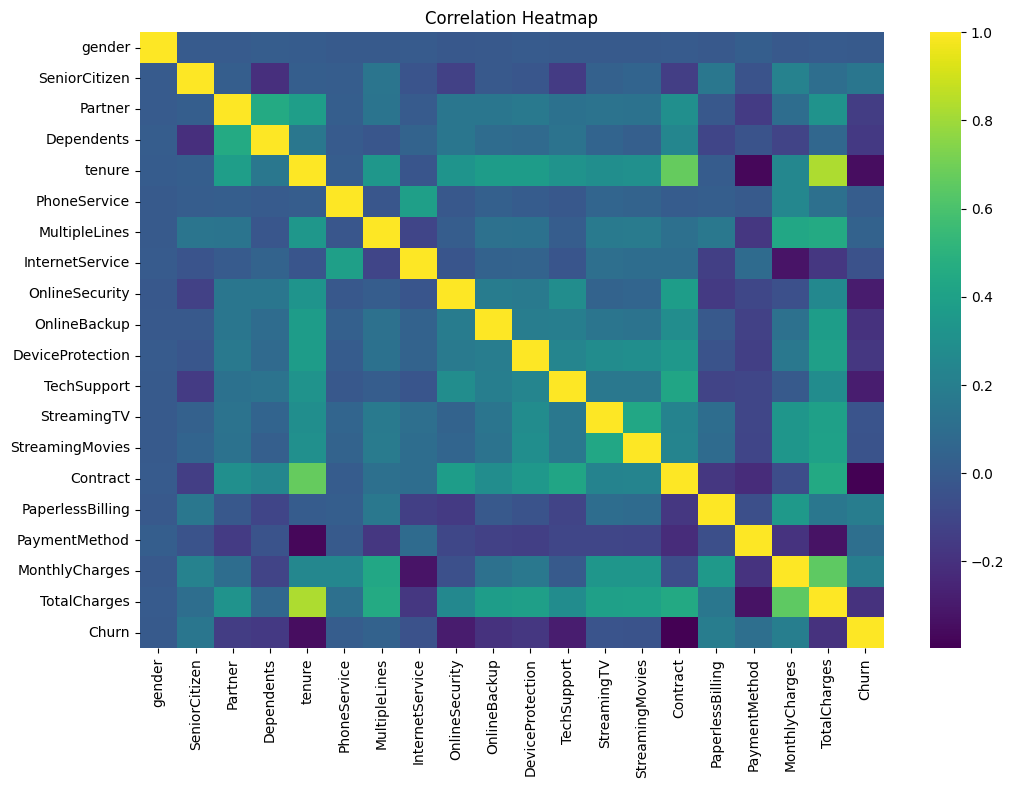

In [15]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="viridis", annot=False)
plt.title("Correlation Heatmap")
plt.show()

FEATURE ENGINEERING

In [16]:
# Create a new feature: AvgChargesPerMonth = TotalCharges / tenure
df["AvgChargesPerMonth"] = df["TotalCharges"] / (df["tenure"] + 1)
df["AvgChargesPerMonth"].fillna(0, inplace=True)

print("\nFeature Engineering Done!")
print(df.head())


Feature Engineering Done!
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0              1                0               0             2  ...   
1              0                0               2             0  ...   
2              0                0               2             2  ...   
3              1                0               2             0  ...   
4              0                1               0             0  ...   

   TechSupport  StreamingTV  StreamingMovies  Contract  PaperlessBilling  \
0            0            0          

C:\Users\91994\AppData\Local\Temp\ipykernel_10900\1120473419.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AvgChargesPerMonth"].fillna(0, inplace=True)


FEATURE SELECTION (Chi2)

In [18]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Normalize data for chi2
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Select top 10 important features
chi2_selector = SelectKBest(score_func=chi2, k=10)
chi2_selector.fit(X_scaled, y)
chi2_scores = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi2_selector.scores_
}).sort_values(by="Chi2 Score", ascending=False)

print("\nTop 10 Features by Chi² Test:")
print(chi2_scores.head(10))


Top 10 Features by Chi² Test:
             Feature  Chi2 Score
14          Contract  557.890083
8     OnlineSecurity  275.805765
11       TechSupport  261.651933
4             tenure  226.096162
1      SeniorCitizen  134.351545
3         Dependents  133.036443
9       OnlineBackup  115.043260
15  PaperlessBilling  105.680863
10  DeviceProtection   95.651570
2            Partner   82.412083


DATA SPLITTING

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nData Split Complete!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



Data Split Complete!
Training samples: 5634
Testing samples: 1409


MODEL BUILDING 

In [21]:
# Initialize model
model = RandomForestClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Model Evaluation:
Accuracy: 0.7828246983676366

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix:
 [[925 110]
 [196 178]]
